In [2]:
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
import seaborn as sns

import pickle
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import ipywidgets as widgets
from IPython.display import display



## Exploratory Data Analysis

# Описание данных проекта «СберАвтоподписка»

Данные выгружены из **Google Analytics** (используется модель атрибуции *last-click*).

---

## 1. GA Sessions (`ga_sessions.pkl`)
Каждая строка в этом датасете соответствует **одному визиту** на сайт.

### Атрибуты:
* `session_id` — уникальный ID визита;
* `client_id` — уникальный ID посетителя;
* `visit_date` — дата визита;
* `visit_time` — время визита;
* `visit_number` — порядковый номер визита данного клиента;
* `utm_source` — канал привлечения;
* `utm_medium` — тип привлечения;
* `utm_campaign` — рекламная кампания;
* `utm_keyword` — ключевое слово;
* `device_category` — тип устройства (mobile, desktop, tablet);
* `device_os` — операционная система устройства;
* `device_brand` — марка устройства;
* `device_model` — модель устройства;
* `device_screen_resolution` — разрешение экрана;
* `device_browser` — браузер;
* `geo_country` — страна;
* `geo_city` — город.

---

## 2. GA Hits (`ga_hits.pkl`)
Каждая строка соответствует **одному событию** (хиту) внутри визита.

### Атрибуты:
* `session_id` — ID визита (ключ для связи с таблицей сессий);
* `hit_date` — дата события;
* `hit_time` — время события;
* `hit_number` — порядковый номер события в рамках одной сессии;
* `hit_type` — тип события;
* `hit_referer` — источник (referer) события;
* `hit_page_path` — путь страницы, на которой произошло событие;
* `event_category` — тип действия;
* `event_action` — конкретное действие;
* `event_label` — тег (метка) действия;
* `event_value` — числовое значение результата действия.



# 1. Разведовательный анализ. Базовый анализ 

In [3]:
tmp_sessions = pd.read_csv('data/ga_sessions.csv')
tmp_hits = pd.read_csv('data/ga_hits.csv')

/var/folders/qj/qtwhwk7s5939qz6m404hrczm0000gn/T/ipykernel_98663/3596395269.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  tmp_sessions = pd.read_csv('data/ga_sessions.csv')


In [4]:
go_session = tmp_sessions.copy()
go_hits = tmp_hits.copy()

In [25]:
tmp_sessions.head(6)

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
5,9055447192389856083.1622453074.1622453074,2108385598.162245,2021-05-31,12:00:00,1,kjsLglQLzykiRbcDiGcD,organic,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,NaN,Apple,NaN,375x812,Safari,Russia,Saint Petersburg


In [5]:
go_session.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Non-Null Count    Dtype 
---  ------                    --------------    ----- 
 0   session_id                1860042 non-null  object
 1   client_id                 1860042 non-null  object
 2   visit_date                1860042 non-null  object
 3   visit_time                1860042 non-null  object
 4   visit_number              1860042 non-null  int64 
 5   utm_source                1859945 non-null  object
 6   utm_medium                1860042 non-null  object
 7   utm_campaign              1640439 non-null  object
 8   utm_adcontent             1524427 non-null  object
 9   utm_keyword               777981 non-null   object
 10  device_category           1860042 non-null  object
 11  device_os                 789904 non-null   object
 12  device_brand              1492864 non-null  object
 13  device_model              16338 non-null  

In [6]:
for col in go_session.columns:
    print( f'графа {col}, {go_session[col].nunique()}')

графа session_id, 1860042
графа client_id, 1391717
графа visit_date, 226
графа visit_time, 85318
графа visit_number, 537
графа utm_source, 293
графа utm_medium, 56
графа utm_campaign, 412
графа utm_adcontent, 286
графа utm_keyword, 1219
графа device_category, 3
графа device_os, 13
графа device_brand, 205
графа device_model, 104
графа device_screen_resolution, 5039
графа device_browser, 57
графа geo_country, 166
графа geo_city, 2548


In [7]:
go_hits.tail(5)

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
15726465,6866159858916559617.1640270865.1640270865,2021-12-23,810589.0,43,event,NaN,sberauto.com/cars/all/toyota/fortuner/24cb5af2...,quiz,quiz_show,NaN,NaN
15726466,7310304587364460692.1640261783.1640261783,2021-12-23,904927.0,40,event,NaN,sberauto.com/cars/all/mercedes-benz/gla-klasse...,quiz,quiz_show,NaN,NaN
15726467,8013702685784312179.1640270195.1640270195,2021-12-23,2172865.0,43,event,NaN,sberauto.com/cars/all/toyota/alphard/2ebe4871?...,quiz,quiz_show,NaN,NaN
15726468,8021505554734405918.1640257821.1640257821,2021-12-23,713325.0,45,event,NaN,sberauto.com/cars/all/bmw/x3/6a660f0a?rental_p...,quiz,quiz_show,NaN,NaN
15726469,1569014437485249865.1640269129.1640269129,2021-12-23,742820.0,46,event,NaN,sberauto.com/cars/all/bmw/7-serii/399ac530?utm...,quiz,quiz_show,NaN,NaN


In [8]:
mask = (go_hits['session_id'] == '1279681186746345207.1640244983.1640244983') 
go_hits[mask].head(2)

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
1555,1279681186746345207.1640244983.1640244983,2021-12-23,1835077.0,162,event,NaN,sberauto.com/cars/all/renault/logan/8c3c73f2?u...,card_web,view_card,NaN,NaN
1577,1279681186746345207.1640244983.1640244983,2021-12-23,1835302.0,164,event,NaN,sberauto.com/cars/all/renault/logan/8c3c73f2?u...,card_web,view_card,NaN,NaN


In [9]:
cols = [ 
         'event_value', 
         'event_label', 
         'event_action', 
         'event_category', 
         'hit_type',
         #'hit_page_path'
         'hit_referer'
        ]  
unique_data = {col: pd.Series(go_hits[col].unique()) for col in cols}

go_hits_unique = pd.DataFrame(unique_data)

go_hits_unique.to_csv('Уникальные значения.csv')

In [10]:
go_categ_action = go_hits.groupby(['event_action'])['event_label'].unique()

display(go_categ_action)
go_categ_action.to_csv('Соответсвие action : label (1:m).csv')

event_action
add_ad_btn                                             [vHXtCZdHtxWtMVFahiDO]
analystlabel                                      [nan, KclpemfoHstknWHFiLit]
auto_subscription_click                                [uDrwlhtkwJJbRcbyRaTW]
automatic_return_to_chat    [ScbSRbaBkoKdXrEFKJRK, lscZObuYWHoNFlwKjIWk, O...
back_to_change_phone                              [nan, KclpemfoHstknWHFiLit]
                                                  ...                        
user_message                [ZVOVdtNXFMFfNhNjnLkV, uHqTpyndZNCTQERMxjfu, l...
view_card                                         [nan, KclpemfoHstknWHFiLit]
view_more_click                                        [pzAKUYdRKNEUXxxBFUPX]
view_new_card                                     [nan, KclpemfoHstknWHFiLit]
view_used_card                                    [nan, KclpemfoHstknWHFiLit]
Name: event_label, Length: 230, dtype: object

In [11]:
go_categ_action = go_hits.groupby(['event_category'])['event_action'].unique()

display(go_categ_action)
go_categ_action.to_csv('Соответсвие category : action (1:m).csv')

event_category
active_invitation                 [showed_active_invitation, click_no_help_needed]
ad_banner                                                           [analystlabel]
add_ad                                                                [add_ad_btn]
add_ad_additional_information         [forward_to_options, backward_to_basic_data]
add_ad_city                                [forward_to_price, backward_to_options]
add_ad_description                       [backward_to_photo, forward_to_documents]
add_ad_documents                     [forward_to_preview, backward_to_description]
add_ad_form                      [survey_buy_after_sell_start, survey_buy_after...
add_ad_options                   [forward_to_city, backward_to_additional_infor...
add_ad_photo                           [forward_to_description, backward_to_price]
add_ad_preview                      [forward_to_to_publish, backward_to_documents]
add_ad_price                                  [forward_to_photo, backwar

In [12]:
go_hits.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 11 columns):
 #   Column          Non-Null Count     Dtype  
---  ------          --------------     -----  
 0   session_id      15726470 non-null  object 
 1   hit_date        15726470 non-null  object 
 2   hit_time        6566148 non-null   float64
 3   hit_number      15726470 non-null  int64  
 4   hit_type        15726470 non-null  object 
 5   hit_referer     9451666 non-null   object 
 6   hit_page_path   15726470 non-null  object 
 7   event_category  15726470 non-null  object 
 8   event_action    15726470 non-null  object 
 9   event_label     11966286 non-null  object 
 10  event_value     0 non-null         float64
dtypes: float64(2), int64(1), object(8)
memory usage: 1.3+ GB


In [18]:
# Ктергория 1 - готовы совершить целевое действие 
# Финальные конверсии и подтвержденные контакты
hot_conversions = [
    "sub_submit_success",          # Успешная отправка заявки на подписку
    "sub_car_request_submit_click", # Клик по кнопке отправки запроса на авто
    "form_request_call_sent",      # Форма заказа звонка успешно отправлена
    "request_success",             # Успешный запрос
    "sub_car_claim_submit_click",  # Клик по подтверждению претензии/заявки
    "sber_id_auth_success",        # Успешная авторизация через Сбер ID
    "phone_auth_success",          # Успешный вход по номеру телефона
    "code_sms_entered_success",    # Правильный ввод SMS-кода
    "success_ad_creation",         # Успешное создание объявления
    "user gave contacts during chat", # Пользователь оставил контакты в чате
    "callback requested"           # Заказан обратный звонок
]

# Финансовые и кредитные действия 
financial_actions = [
    "setelem_credit_form_button",  # Клик по кнопке кредитной формы Сетелем
    "click_setelem_credit",        # В кредит у Сетелем
    "click_on_credit_btn",         # Клик по кнопке "В кредит"
    "click_pos_credit",            # Клик по POS кредитованию (экспресс кредит )
    "click_credit",                # го в кредиттный раздел 
    "greenday_sub_submit_success"  # Заявка по акции Green Day согласована
]



# Заполнение формы 
warm_intent = [
    "click_free_car_selection",    # Запрос на бесплатный подбор авто
    "click_on_help_in_finding",    # Клик "Помочь с поиском"
    "quiz_start",                  # Старт подбора
    "start_auth",                  # Начало процесса авторизации
    "phone_entered",               # Введен номер телефона 
    "name_entered",                # Введено имя
    "sub_car_claim_click",         # Клик по оформлению заявки
    "click_on_subscription",       # Клик по кнопке "Подписаться"
    "calculate",                   # Нажата кнопка "Рассчитать"
    "client initiate chat"         # Пользователь первым написал в чат
]

# Ктергория 2 - почти готовы  
# Просмотр конкретных объектов
view_actions = [
    "go_to_car_card",              # Переход в карточку автомобиля
    "view_new_card",               # Просмотр карточки нового авто
    "view_used_card",              # Просмотр карточки б/у авто
    "view_card",                   # Общий просмотр карточки
    "sub_car_page"                 # Просмотр страницы подписки
]


# Фильтры и поиск 
search_filters = [
    "search_form_mark_select",     # Выбор марки
    "search_form_model_select",    # Выбор модели
    "search_form_cost_from",       # Цена ОТ
    "search_form_cost_to",         # Цена ДО
    "search_form_year_from",       # Год выпуска ОТ
    "search_body_type",            # Выбор типа кузова
    "search_engine",               # Выбор типа двигателя
    "search_kpp",                  # Выбор коробки передач
    "search_drive",                # Выбор привода
    "sub_view_cars_click"          # Клик по кнопке "Посмотреть все авто"
]


# Ктергория 3 -  не готовы 
# Поиск информации 
awareness_actions = [
    "potential_banner_click",      # Клик по акционному баннеру
    "sub_banner_click",            # Клик по баннеру подписки
    "click_on_menu",               # Клик по меню навигации
    "sub_view_faq_click",          # Просмотр часто задаваемых вопросов
    "scrolling_to_advantages",     # Скролл до блока преимуществ
    "click_on_logo",               # Клик по логотипу
    "go_to_special_offers"         # Переход в спецпредложения
    "tinkoff_credit_form_button",  # Тинькофф - ????
    "sravni_credit_form_button"    # Сравни.ру - ????
]


Вывод: 


- utm_source - заполнитьь модой 
- utm_medium - заполнитьь модой               
- utm_campaign - заполнитьь модой 
- utm_adcontent - заполнитьь модой 
- device_brand - заполнитьь модой
----------------------------------------------

- session_id - удалить столбец
- client_id: удалить  столбец
- utm_keyword  - удалить столбец 
- device_os - удалить столбец
- device_model - удалить столбецк
----------------------------------------------

- из visit_date достать: праздничный/выходной  
- из visit_time сделать диапазоны 
----------------------------------------------

- device_screen_resolution: 393x786 : разделить через x и пермножить в float
----------------------------------------------

- geo_city:  взять 20 популярных и перевести в параметр , остальные прочее 
- geo_country:  взять 10 популярных и перевести в параметр , остальные прочее 
- device_browser:  взять 10 популярных и перевести в параметр , остальные прочее 
- device_brand:  взять 10 популярных и перевести в параметр , остальные прочее 
- device_category: оставляем текущие категории 
----------------------------------------------

- utm_source  взять 10 популярных и перевести в параметр , остальные прочее 
- utm_medium  взять 10 популярных и перевести в параметр , остальные прочее 
- utm_campaign  взять 15 популярных и перевести в параметр , остальные прочее 
- utm_adcontent  взять 10 популярных и перевести в параметр , остальные прочее 
----------------------------------------------


- добавить прзнак события 1 группы, события 2-ой группы, событитя 3-ей группы из hit
----------------------------------------------


# 2. Создаем модули обработки данных для модели 

In [15]:
def set_moda(data, col):
    
    data[col].fillna(data[col].mode()[0], inplace=True)
    print(f'{col}: {data[col].mode()[0]}')

#       Моды на которых учили 
#       utm_source: ZpYIoDJMcFzVoPFsHGJL
#       utm_medium: banner
#       utm_campaign: LTuZkdKfxRGVceoWkVyg
#       utm_adcontent: JNHcPlZPxEMWDnRiyoBf
#       device_brand: Apple
    
    return data 

In [7]:
def drop_col(data, col): 
    data.drop([col], axis = 1, inplace=True)
    return data

In [8]:
def set_date_feature(data, col_date, col_time): 
    
    data['visit_datetime'] = pd.to_datetime(data[col_date] + ' ' + data[col_time])

    date_time = data['visit_datetime'].dt

    # Временные отрезки
    data['visit_hour']   = date_time.hour           
    data['visit_minute'] = date_time.minute       
    data['visit_second'] = date_time.second      


    # Календарные признаки
    data['visit_day_of_week'] = date_time.dayofweek  
    data['visit_month']       = date_time.month          
    data['visit_is_year_end'] = date_time.is_year_end.astype(int)  
    
        # Периоды суток (Custom feature)
    def get_part_of_day(h):
        if 6 <= h < 12: return 'morning'
        elif 12 <= h < 18: return 'afternon'
        elif 18 <= h < 24: return 'evening'
        else: return 'night'

    data['visit_part_of_day'] = data['visit_hour'].apply(get_part_of_day) 

    data.drop([col_date], axis = 1, inplace=True)
    data.drop([col_time], axis = 1, inplace=True)
    data.drop(['visit_datetime'], axis = 1, inplace=True)

    return data

In [14]:
def set_mult(data, col): 
    data['screen_area'] = data[col].str.split('x').apply(lambda x: float(x[0]) * float(x[1]) if isinstance(x, list) and len(x) == 2 else 0.0)

    data.drop([col], axis = 1, inplace=True)
    return data

In [10]:
def leave_only_top_val(data, col, n, mode=1):
    cat_uniq_data = pd.DataFrame()
    
    if mode == 1:
        # Находим 20 самых топовых значений  
        top_n = data[col].value_counts().nlargest(n).index

    if mode == 2:
        if not cat_uniq_data:  # type: ignore
            cat_uniq_data = pd.read_csv('data/cat_uniq_data.csv')
        top_n = cat_uniq_data[col].value_counts().nlargest(n).index

    top_n = top_n.drop(['(none)', '(not set)', 'other'], errors='ignore') # type: ignore
    # их оставим, остальное заменяем на 'other'
    data[col] = data[col].where(data[col].isin(top_n), 'other')
    return data

In [11]:
def calc_conversion(session, hits, groupby_col, key_cols, cols_pref):
    col_count_name = f'{cols_pref}_count'
    col_is_name    = f'{cols_pref}_is'
    # кол-во целевых action за сессию 
    conv_counts = hits[hits[groupby_col].isin(hot_conversions)].groupby(key_cols).size()

    # добавляем столбец 
    session[col_count_name] = session[key_cols].map(conv_counts).fillna(0).astype(int)

    # добавляем бинар-признак - было или нет 
    session[col_is_name] = (session[col_count_name] > 0).astype(int)

    session.drop([col_count_name], axis = 1, inplace=True)
    return session

In [20]:
go_session = tmp_sessions.copy()

In [21]:
# делаем предполагаемые трансформации 
# ## удалить столбец
#session_id 
#client_id
#utm_keyword 
#device_os
#device_model 

go_session = drop_col(go_session, 'client_id')
go_session = drop_col(go_session, 'utm_keyword')
go_session = drop_col(go_session, 'device_os' )
go_session = drop_col(go_session,  'device_model')



# ## заполнить модой 
# utm_source 
# utm_medium              
# utm_campaign
# utm_adcontent
# device_brand

go_session = set_moda(go_session, 'utm_source')
go_session = set_moda(go_session, 'utm_medium')
go_session = set_moda(go_session, 'utm_campaign')
go_session = set_moda(go_session, 'utm_adcontent')
go_session = set_moda(go_session, 'device_brand')

# ## Обработка даты и времени 
# из visit_date достать: праздничный/выходной  
# из visit_time сделать диапазоны 
go_session = set_date_feature(go_session, 'visit_date', 'visit_time')


# расширение 
# device_screen_resolution: 393x786 : разделить через x и пермножить в float
go_session = set_mult(go_session, 'device_screen_resolution')


#  Категориальные признаки 
# geo_city:  взять 20 популярных и перевести в параметр , остальные прочее 
# geo_country:  взять 10 популярных и перевести в параметр , остальные прочее 
# device_browser:  взять 10 популярных и перевести в параметр , остальные прочее 
# device_brand:  взять 10 популярных и перевести в параметр , остальные прочее 
# utm_source  взять 10 популярных и перевести в параметр , остальные прочее 
# utm_medium  взять 10 популярных и перевести в параметр , остальные прочее 
# utm_campaign  взять 15 популярных и перевести в параметр , остальные прочее 
# utm_adcontent  взять 10 популярных и перевести в параметр , остальные прочее 

go_session = leave_only_top_val(go_session, 'geo_city', 20  )
go_session = leave_only_top_val(go_session, 'geo_country', 10  )
go_session = leave_only_top_val(go_session, 'device_browser', 10  )
go_session = leave_only_top_val(go_session, 'device_brand', 10  )
go_session = leave_only_top_val(go_session, 'utm_source', 10  )
go_session = leave_only_top_val(go_session, 'utm_medium', 10  )
go_session = leave_only_top_val(go_session, 'utm_campaign', 15  )
go_session = leave_only_top_val(go_session, 'utm_adcontent', 10  )


# добавляем итоговые  события 
#  добавить прзнак события 1 группы, события 2-ой группы, событитя 3-ей группы из hit

go_session = calc_conversion(go_session, go_hits, 'event_action', 'session_id', 'target')

go_session = drop_col(go_session, 'session_id')

utm_source: ZpYIoDJMcFzVoPFsHGJL
utm_medium: banner
utm_campaign: LTuZkdKfxRGVceoWkVyg
utm_adcontent: JNHcPlZPxEMWDnRiyoBf
device_brand: Apple


In [22]:
go_session.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 19 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   visit_number       1860042 non-null  int64  
 1   utm_source         1860042 non-null  object 
 2   utm_medium         1860042 non-null  object 
 3   utm_campaign       1860042 non-null  object 
 4   utm_adcontent      1860042 non-null  object 
 5   device_category    1860042 non-null  object 
 6   device_brand       1860042 non-null  object 
 7   device_browser     1860042 non-null  object 
 8   geo_country        1860042 non-null  object 
 9   geo_city           1860042 non-null  object 
 10  visit_hour         1860042 non-null  int32  
 11  visit_minute       1860042 non-null  int32  
 12  visit_second       1860042 non-null  int32  
 13  visit_day_of_week  1860042 non-null  int32  
 14  visit_month        1860042 non-null  int32  
 15  visit_is_year_end  1860042 non-n

In [25]:
unique_data2 = go_session['target_is'].unique().tolist()
print(unique_data2)

[0, 1]


In [23]:
go_session[go_session['target_is'] == 1].head(5)

,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,device_category,device_brand,device_browser,geo_country,geo_city,visit_hour,visit_minute,visit_second,visit_day_of_week,visit_month,visit_is_year_end,visit_part_of_day,screen_area,target_is
5,1,kjsLglQLzykiRbcDiGcD,organic,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,mobile,Apple,Safari,Russia,Saint Petersburg,12,0,0,0,5,0,afternon,304500.0,1
75,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,mobile,Apple,Safari,Russia,Samara,21,10,7,0,11,0,evening,304704.0,1
78,1,BHcvLfOaCWvWTykYqHVe,cpc,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,desktop,Apple,Safari,Russia,other,22,0,0,0,6,0,evening,927408.0,1
102,1,fDLlAcSmythWSCVMvqvL,other,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,mobile,Apple,Safari (in-app),Russia,Moscow,22,0,0,6,8,0,evening,250125.0,1
157,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,mobile,OPPO,Chrome,Russia,Moscow,16,52,54,0,11,0,afternon,288000.0,1


In [26]:
cat_features = list(go_session.select_dtypes(include=['object', 'category']).columns)

unique_data = {col: pd.Series(go_session[col].unique()) for col in cat_features}

go_session_unique = pd.DataFrame(unique_data)

go_session_unique.to_csv('data/cat_uniq_data.csv')

In [27]:
# отделяем тарггет  на X и y
X = go_session.drop(['target_is'], axis=1)
y = go_session['target_is']

# Определяем категориальные признаки (кроме float/int)
cat_features = list(X.select_dtypes(include=['object', 'category']).columns)

# Распеодеяем тест и обучение  данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Инициализация модели
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC', 
    random_seed=42,
    verbose=100,
    auto_class_weights='Balanced',
    early_stopping_rounds=100,
)

# Обучение
model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    plot=True  
)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.6596182	best: 0.6596182 (0)	total: 4.52s	remaining: 37m 35s
100:	test: 0.7203306	best: 0.7203306 (100)	total: 5m 45s	remaining: 22m 44s
200:	test: 0.7279205	best: 0.7279205 (200)	total: 11m 18s	remaining: 16m 49s
300:	test: 0.7317189	best: 0.7317189 (300)	total: 15m 48s	remaining: 10m 27s
400:	test: 0.7351406	best: 0.7351406 (400)	total: 20m 18s	remaining: 5m
499:	test: 0.7358858	best: 0.7360292 (488)	total: 24m 53s	remaining: 0us

bestTest = 0.736029244
bestIteration = 488

Shrink model to first 489 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=6, early_stopping_rounds=100, eval_metric='AUC', iterations=500, learning_rate=0.05, random_seed=42, verbose=100)

In [29]:
# Посмотреть важность признаков
import pandas as pd
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.get_feature_importance()
}).sort_values(by='importance', ascending=False)
print(feature_importance.head(30))

              feature  importance
4       utm_adcontent   18.569725
1          utm_source   12.247757
2          utm_medium   10.720237
17        screen_area    9.741750
3        utm_campaign    9.468462
14        visit_month    7.576911
0        visit_number    7.154159
5     device_category    4.003751
7      device_browser    3.600175
6        device_brand    2.712989
8         geo_country    2.451589
10         visit_hour    2.226801
15  visit_is_year_end    2.146221
12       visit_second    1.798181
9            geo_city    1.656676
11       visit_minute    1.650144
13  visit_day_of_week    1.316978
16  visit_part_of_day    0.957494


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import pandas as pd

#Получаем предсказания
preds = model.predict(X_test)          # Классы (0 или 1)
probs = model.predict_proba(X_test)[:, 1] # Вероятности 

# Выводим основные метрики 
print('Отчет по классификации:')
print(classification_report(y_test, preds))

# Выводим AUC-ROC  
auc = roc_auc_score(y_test, probs)
print(f'ROC-AUC на тестовой выборке: {auc:.4f}')

# Матрица ошибок
print('\nМатрица ошибок:')
print(pd.crosstab(y_test, preds, rownames=['Actual'], colnames=['Predicted']))


Отчет по классификации:
              precision    recall  f1-score   support

           0       0.99      0.60      0.75    366722
           1       0.03      0.72      0.05      5287

    accuracy                           0.60    372009
   macro avg       0.51      0.66      0.40    372009
weighted avg       0.98      0.60      0.74    372009

ROC-AUC на тестовой выборке: 0.7360

Матрица ошибок:
Predicted       0       1
Actual                   
0          218593  148129
1            1455    3832


In [37]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 372009 entries, 27342 to 1220767
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   visit_number       372009 non-null  int64  
 1   utm_source         372009 non-null  object 
 2   utm_medium         372009 non-null  object 
 3   utm_campaign       372009 non-null  object 
 4   utm_adcontent      372009 non-null  object 
 5   device_category    372009 non-null  object 
 6   device_brand       372009 non-null  object 
 7   device_browser     372009 non-null  object 
 8   geo_country        372009 non-null  object 
 9   geo_city           372009 non-null  object 
 10  visit_hour         372009 non-null  int32  
 11  visit_minute       372009 non-null  int32  
 12  visit_second       372009 non-null  int32  
 13  visit_day_of_week  372009 non-null  int32  
 14  visit_month        372009 non-null  int32  
 15  visit_is_year_end  372009 non-null  int64  
 16  vi

при обучении модели на полном объеме

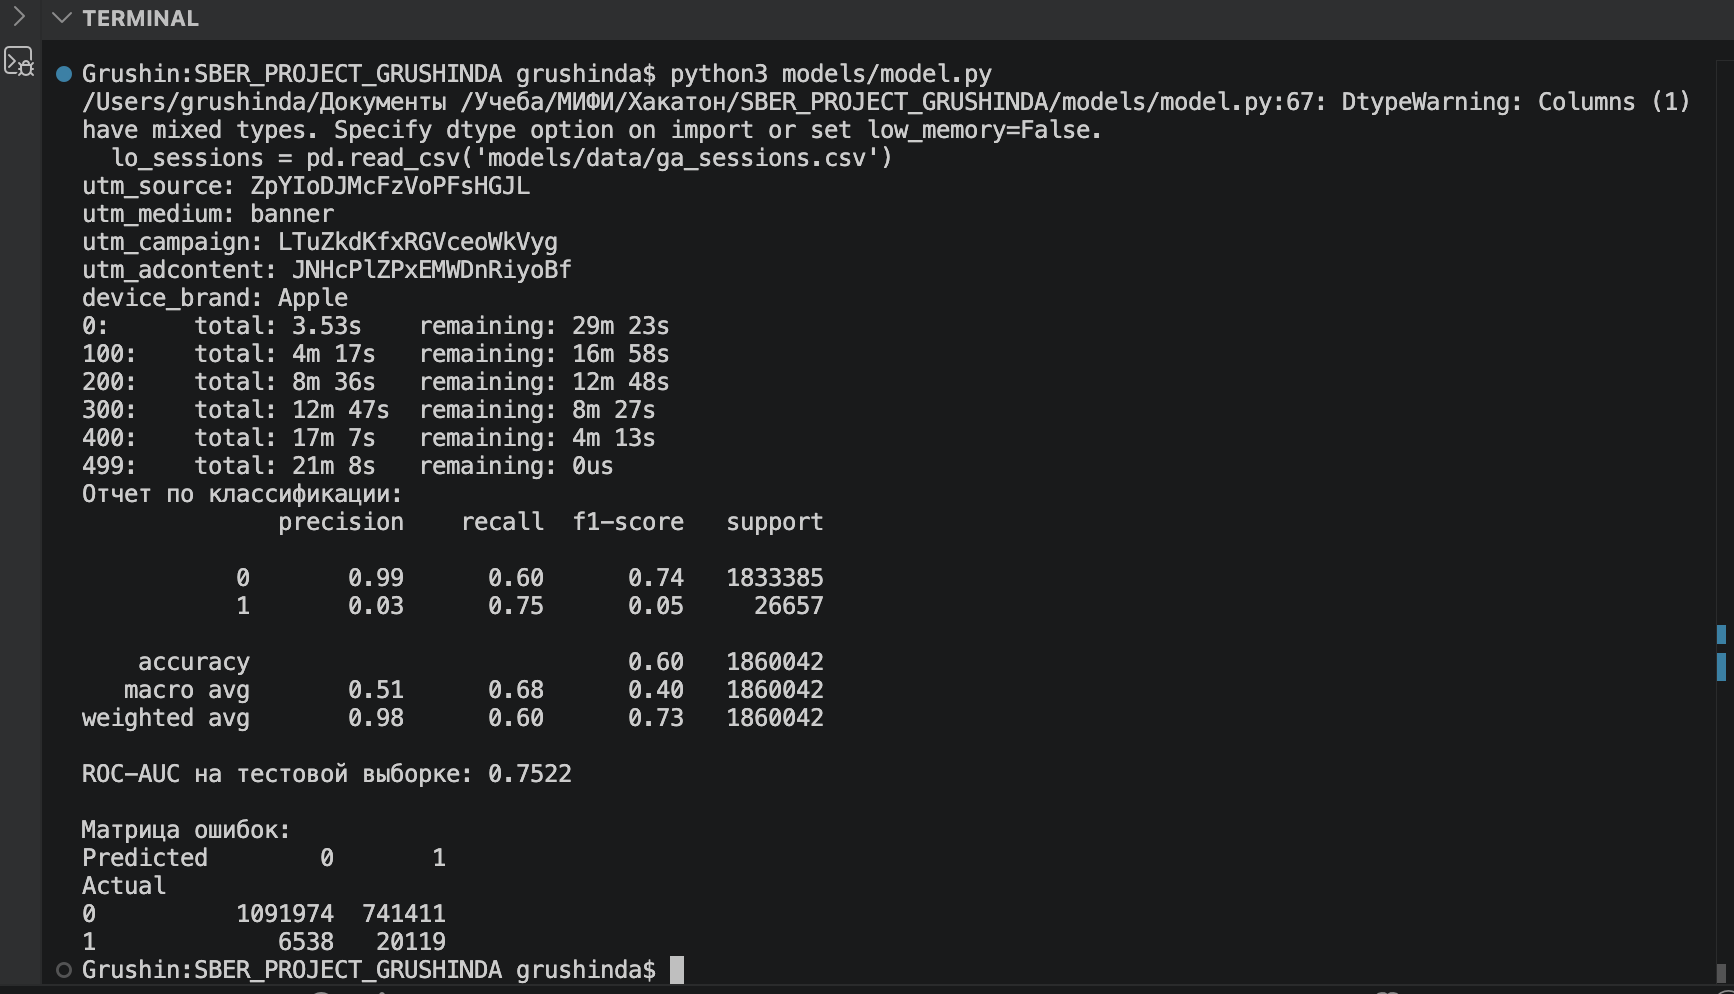